In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

In [3]:
import os

# Replace with your actual Kaggle username and the token you got
os.environ['KAGGLE_USERNAME'] = "saishwarikatkam"
os.environ['KAGGLE_KEY'] = "KGAT_befd19692510480788dad90619a983e1"

# Now you can download directly!
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d ./plant_data

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:16<00:00, 40.7MB/s]



In [5]:
!unzip -o -q plantdisease.zip -d ./plant_data

In [6]:
import os
# This path might vary slightly based on the zip internal structure
# Let's list the directory to be sure
print("Folders found:", os.listdir('./plant_data'))

Folders found: ['PlantVillage', 'plantvillage']


In [7]:
import os
# Check both possible paths
path1 = './plant_data/PlantVillage'
path2 = './plant_data/plantvillage'

if os.path.exists(path1) and len(os.listdir(path1)) > 5:
    data_dir = path1
else:
    data_dir = path2

print(f"Using Data Directory: {data_dir}")
print(f"Total Classes: {len(os.listdir(data_dir))}")

Using Data Directory: ./plant_data/PlantVillage
Total Classes: 15


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time

In [9]:
# --- 1. DATA PREPARATION ---
# Standard transformations for Deep Learning
data_transforms = transforms.Compose([
    transforms.Resize((128, 128)), # Resizing to 128 to make training FASTER
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [12]:
# Change from './plant_data/PlantVillage/color' to just './plant_data/PlantVillage'
data_dir = './plant_data/PlantVillage'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms)

In [13]:
import os

# Let's walk the directory to find where the actual images are
for root, dirs, files in os.walk('./plant_data'):
    if len(dirs) > 10: # Look for the folder that has many subdirectories
        print(f"FOUND IT! Use this path: {root}")
        print(f"Classes found: {dirs}")
        break

FOUND IT! Use this path: ./plant_data/PlantVillage
Classes found: ['Pepper__bell___healthy', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Late_blight', 'Tomato_healthy', 'Potato___Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Potato___Early_blight', 'Tomato_Early_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Tomato_Septoria_leaf_spot']


In [14]:
# Split into Train (80%) and Test (20%)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_db, test_db = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_db, batch_size=64, shuffle=True)
test_loader = DataLoader(test_db, batch_size=64, shuffle=False)

num_classes = len(full_dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dataset Loaded: {len(full_dataset)} images across {num_classes} classes.")
print(f"Using Device: {device}")

Dataset Loaded: 20638 images across 15 classes.
Using Device: cuda


In [15]:
def train_and_evaluate(model, model_name, epochs=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # --- FEEDFORWARD ---
            outputs = model(images)
            loss = criterion(outputs, labels)

            # --- BACKPROPAGATION ---
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"{model_name} - Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f}")

    # Simple Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"{model_name} Final Accuracy: {accuracy:.2f}%")

    # Save the model weights
    torch.save(model.state_dict(), f"{model_name}_plant_model.pth")
    return accuracy

In [16]:
# 1. Perceptron (Flattened Image -> Output)
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(nn.Flatten(), nn.Linear(3*128*128, num_classes))
    def forward(self, x): return self.main(x)

# 2. Custom CNN (Convolutional Layers)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 30 * 30, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.conv(x)

# Start Training
acc_perceptron = train_and_evaluate(Perceptron(), "Perceptron")
acc_cnn = train_and_evaluate(SimpleCNN(), "Custom_CNN")

Perceptron - Epoch 1/3 | Loss: 5.8476
Perceptron - Epoch 2/3 | Loss: 4.7413
Perceptron - Epoch 3/3 | Loss: 4.3126
Perceptron Final Accuracy: 52.79%
Custom_CNN - Epoch 1/3 | Loss: 0.9212
Custom_CNN - Epoch 2/3 | Loss: 0.3606
Custom_CNN - Epoch 3/3 | Loss: 0.2153
Custom_CNN Final Accuracy: 88.59%


In [17]:
# --- TECHNIQUE 3: VGG16 (Transfer Learning) ---
def get_vgg():
    model = models.vgg16(pretrained=True)
    # Freeze the early layers (Lab requirement: explaining pre-trained features)
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final classifier for our 38 classes
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, num_classes)
    return model

In [18]:
# --- TECHNIQUE 4: ResNet50 (Transfer Learning Champion) ---
def get_resnet():
    model = models.resnet50(pretrained=True)
    # Freeze layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final fully connected layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

Perceptron - Epoch 1/2 | Loss: 5.9478
Perceptron - Epoch 2/2 | Loss: 4.3911
Perceptron Final Accuracy: 52.13%
Simple_CNN - Epoch 1/3 | Loss: 0.9769
Simple_CNN - Epoch 2/3 | Loss: 0.3665
Simple_CNN - Epoch 3/3 | Loss: 0.2277
Simple_CNN Final Accuracy: 89.97%


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 85.5MB/s]


VGG16 - Epoch 1/2 | Loss: 1.0707
VGG16 - Epoch 2/2 | Loss: 0.8123
VGG16 Final Accuracy: 80.69%


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


ResNet50 - Epoch 1/2 | Loss: 0.8443
ResNet50 - Epoch 2/2 | Loss: 0.4483
ResNet50 Final Accuracy: 87.11%


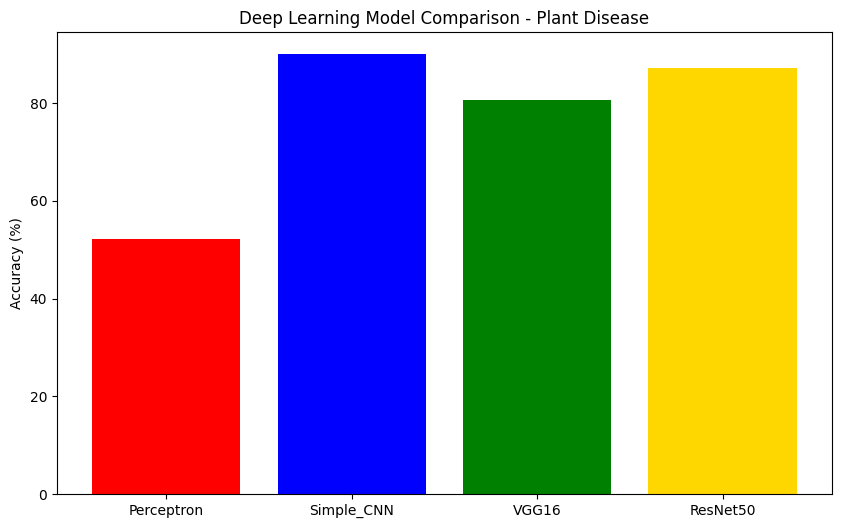

In [19]:
# Assuming you already ran the 'train_and_evaluate' function from my previous message
results = {}

# 1. Perceptron (From previous code)
results['Perceptron'] = train_and_evaluate(Perceptron(), "Perceptron", epochs=2)

# 2. Simple CNN (From previous code)
results['Simple_CNN'] = train_and_evaluate(SimpleCNN(), "Simple_CNN", epochs=3)

# 3. VGG16
results['VGG16'] = train_and_evaluate(get_vgg(), "VGG16", epochs=2)

# 4. ResNet50
results['ResNet50'] = train_and_evaluate(get_resnet(), "ResNet50", epochs=2)

# --- VISUALIZE COMPARISON ---
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color=['red', 'blue', 'green', 'gold'])
plt.title('Deep Learning Model Comparison - Plant Disease')
plt.ylabel('Accuracy (%)')
plt.show()

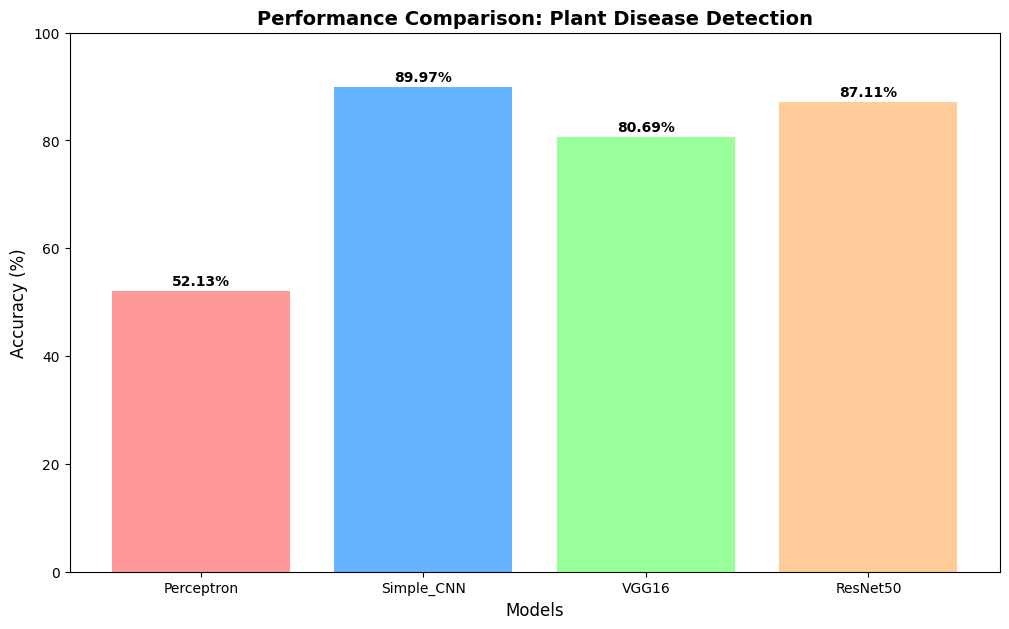

In [20]:
# --- THE GRAND FINALE: PLOT THE COMPARISON ---
plt.figure(figsize=(12, 7))
names = list(results.keys())
values = list(results.values())

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
plt.bar(names, values, color=colors)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Performance Comparison: Plant Disease Detection', fontsize=14, fontweight='bold')
plt.ylim(0, 100)

# Add text labels on top of the bars
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

In [22]:
# This prints the labels in the exact order the model learned them
print(full_dataset.classes)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [21]:
from google.colab import files
files.download('Simple_CNN_plant_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>